### Кластеризация

### Загрузка библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score

### Загрузка датасета

In [2]:
df = pd.read_csv("patient_segmentation_dataset.csv")

### Задаем ключевые переменные

In [3]:
FEATURES = ['Preventive_Care_Flag', 'Num_Chronic_Conditions', 'BMI']

In [4]:
X = df[FEATURES].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Метод локтя

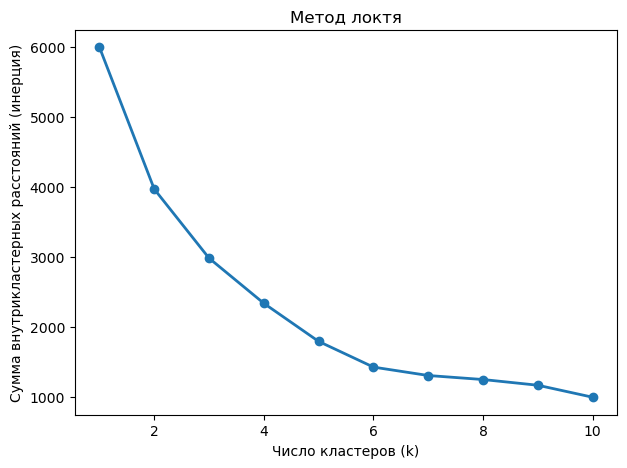

In [5]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertia, marker='o', linewidth=2)
plt.title("Метод локтя")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Сумма внутрикластерных расстояний (инерция)")
plt.show()

Прям явный сгиб не наблюдается, я думаю он есть в точке 6

### Проведем методы кластеризации

In [9]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=2)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=6, linkage='ward')
df['cluster_agg'] = agg.fit_predict(X_scaled)

Выведем метрики

In [10]:
def print_metrics(labels, name):
    if len(set(labels)) < 2:
        print(f"{name}: недостаточно кластеров")
        return
    sil = silhouette_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    print(f"{name} - Sil: {sil:.3f}   CH: {ch:.1f}")

print_metrics(df['cluster_kmeans'], "KMeans")
print_metrics(df['cluster_dbscan'], "DBSCAN")
print_metrics(df['cluster_agg'], "Agglomerative")

KMeans - Sil: 0.429   CH: 1273.8
DBSCAN - Sil: 0.321   CH: 504.7
Agglomerative - Sil: 0.411   CH: 1158.8


In [11]:
print("\nKMeans кластеры:")
print(df.groupby('cluster_kmeans')[FEATURES].mean().round(2))
print("\nDBSCAN кластеры:")
print(df.groupby('cluster_dbscan')[FEATURES].mean().round(2))
print("\nAgglomerativeClustering кластеры:")
print(df.groupby('cluster_agg')[FEATURES].mean().round(2))


KMeans кластеры:
                Preventive_Care_Flag  Num_Chronic_Conditions    BMI
cluster_kmeans                                                     
0                                0.0                    0.77  39.81
1                                0.0                    0.58  24.41
2                                1.0                    0.82  39.55
3                                0.0                    2.53  29.47
4                                1.0                    2.62  30.35
5                                1.0                    0.77  24.38

DBSCAN кластеры:
                Preventive_Care_Flag  Num_Chronic_Conditions    BMI
cluster_dbscan                                                     
-1                               1.0                     2.0  56.60
 0                               0.0                     3.0  30.12
 1                               0.0                     1.0  31.06
 2                               1.0                     1.0  31.07
 3          

Графически выведем методы

KMeans

C:\Users\Muham\AppData\Local\Temp\ipykernel_113400\4140788165.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


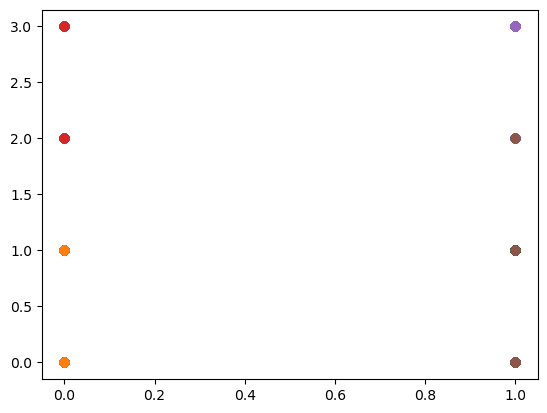

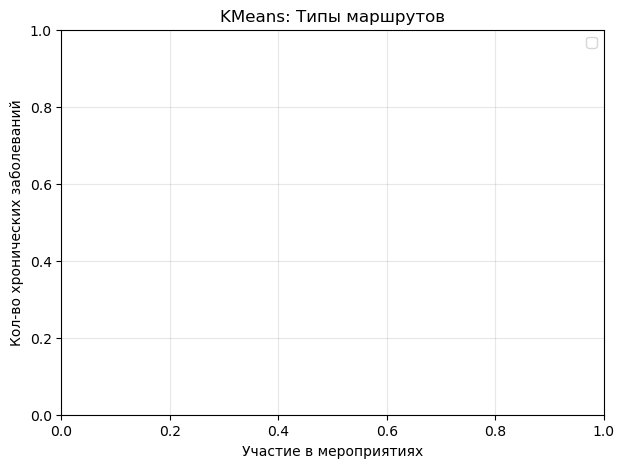

In [16]:
for cid in sorted(df['cluster_kmeans'].unique()):
    mask = df['cluster_kmeans'] == cid
    plt.scatter(
        df['Preventive_Care_Flag'][mask], 
        df['Num_Chronic_Conditions'][mask],
        label=f'Кластер {cid}' if cid >= 0 else 'Шум'
    )

plt.figure(figsize=(7,5))
plt.title('KMeans: Типы маршрутов')
plt.xlabel('Участие в мероприятиях')
plt.ylabel('Кол-во хронических заболеваний')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

DBSCAN

C:\Users\Muham\AppData\Local\Temp\ipykernel_113400\3451456423.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


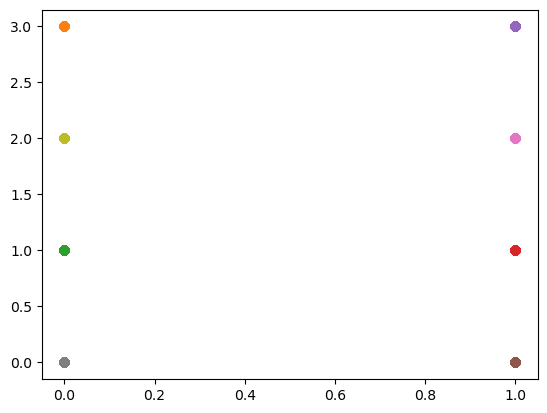

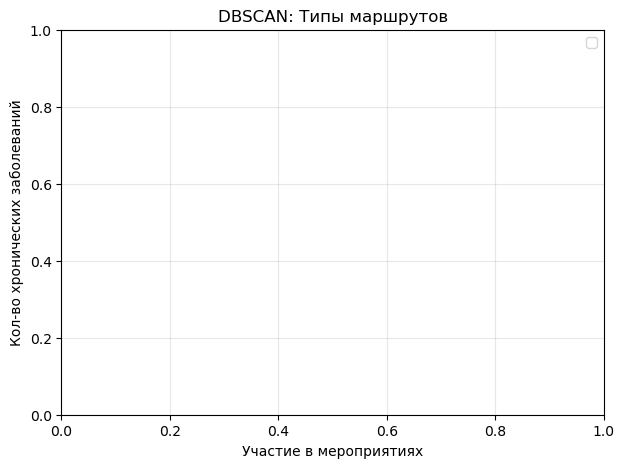

In [17]:
for cid in sorted(df['cluster_dbscan'].unique()):
    mask = df['cluster_dbscan'] == cid
    plt.scatter(
        df['Preventive_Care_Flag'][mask], 
        df['Num_Chronic_Conditions'][mask],
        label=f'Кластер {cid}' if cid >= 0 else 'Шум'
    )

plt.figure(figsize=(7,5))
plt.title('DBSCAN: Типы маршрутов')
plt.xlabel('Участие в мероприятиях')
plt.ylabel('Кол-во хронических заболеваний')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

AgglomerativeClustering

C:\Users\Muham\AppData\Local\Temp\ipykernel_113400\52505310.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


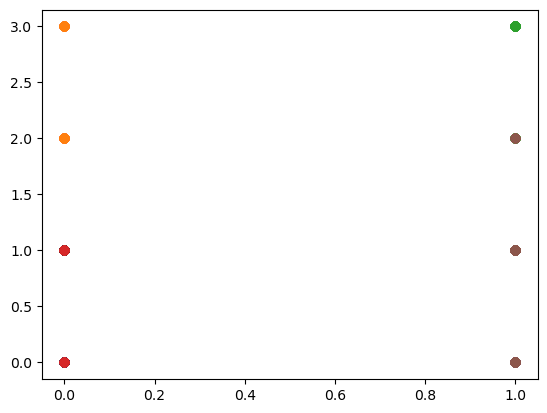

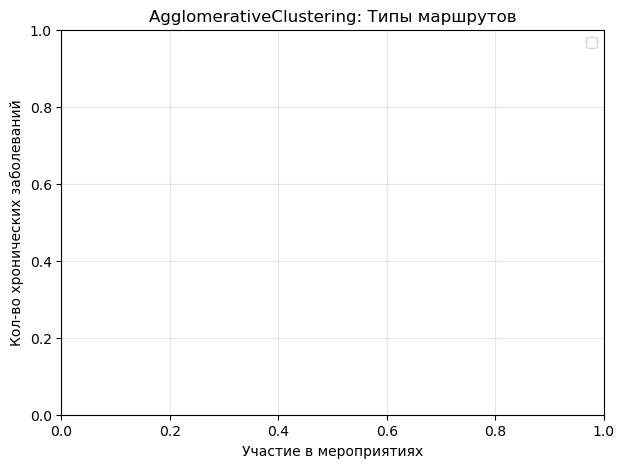

In [18]:
for cid in sorted(df['cluster_agg'].unique()):
    mask = df['cluster_agg'] == cid
    plt.scatter(
        df['Preventive_Care_Flag'][mask], 
        df['Num_Chronic_Conditions'][mask],
        label=f'Кластер {cid}' if cid >= 0 else 'Шум'
    )

plt.figure(figsize=(7,5))
plt.title('AgglomerativeClustering: Типы маршрутов')
plt.xlabel('Участие в мероприятиях')
plt.ylabel('Кол-во хронических заболеваний')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Мягко говоря, графики получились похожими

### Вывод

Самые лучшие результаты показал метод KMeans